# SCM22108 — Sistemas de Comunicação
## Laboratório: Modulação e Demodulação BFSK

**Curso:** Engenharia Eletrônica – IFSC, Florianópolis



---
## 0. Preparação do ambiente

Execute a célula abaixo para importar as bibliotecas necessárias.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.special import erfc
import hashlib

plt.rcParams['figure.figsize'] = (10, 4)


---
## 1. Parâmetros individualizados

Preencha sua matrícula abaixo. A função `parametros_individualizados` deriva,
de forma determinística, um conjunto de parâmetros **único para você**: a
frequência $f_1$, a frequência $f_2$, a duração de bit $T_b$ e a sequência de
16 bits que você vai modular. Rode a célula e **não altere os valores
gerados** — todo o restante do laboratório deve usar exatamente esses
parâmetros.

In [13]:
MATRICULA = "202210505875"

def parametros_individualizados(matricula: str):
    """Gera parametros deterministicos (mas unicos por aluno) a partir da matricula."""
    h = hashlib.sha256(matricula.encode()).hexdigest()
    seed = int(h[:8], 16)
    rng = np.random.default_rng(seed)

    Tb = 1e-3                      # duracao de bit fixa, em segundos (1 ms)
    f1 = 2000 + (seed % 10) * 200  # Hz
    delta_min = 1 / (2 * Tb)       # espacamento minimo p/ ortogonalidade coerente
    # fator entre 0.5x e 1.5x do espacamento minimo -> para ALGUNS alunos
    # a ortogonalidade estrita nao sera satisfeita (isso e proposital, ver Secao 6)
    fator = 0.5 + (seed % 100) / 100.0
    f2 = f1 + fator * delta_min

    bits = rng.integers(0, 2, size=16)

    return {"seed": seed, "Tb": Tb, "f1": f1, "f2": f2,
            "delta_min": delta_min, "fator_delta": fator, "bits": bits}

params = parametros_individualizados(MATRICULA)
for k, v in params.items():
    print(f"{k}: {v}")


seed: 2433319321
Tb: 0.001
f1: 2200
f2: 2555.0
delta_min: 500.0
fator_delta: 0.71
bits: [1 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1]


> **Atenção:** guarde o valor de `fator_delta` impresso acima — ele indica se
> a sua dupla de frequências satisfaz ou não a condição clássica de
> ortogonalidade para FSK coerente. Isso será relevante na Seção 6.

---
## 2. Modulador BFSK

Implemente o modulador BFSK coerente segundo o diagrama de blocos abaixo,
**usando exatamente os parâmetros da Seção 1** (`f1`, `f2`, `Tb`, `bits`).

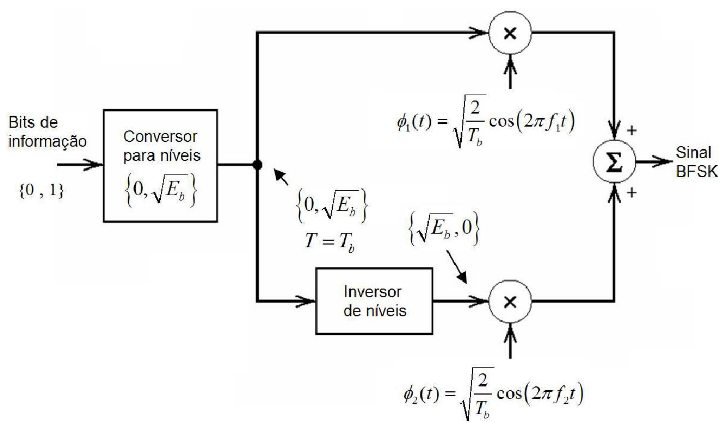

**Observações sobre os blocos:**

a) O bloco **Conversor para níveis** é apenas um codificador NRZ unipolar:
   bit 0 → nível 0; bit 1 → nível $\sqrt{E_b}$.

b) O bloco **Inversor de níveis** troca a amplitude do sinal: onde a
   amplitude é zero, a saída é $\sqrt{E_b}$; onde a amplitude é
   $\sqrt{E_b}$, a saída é zero.

c) As funções-base são:
$$\phi_1(t) = \sqrt{\frac{2}{T_b}}\cos(2\pi f_1 t), \qquad
  \phi_2(t) = \sqrt{\frac{2}{T_b}}\cos(2\pi f_2 t)$$

**O que fazer:**
1. Complete a função `modula_bfsk` abaixo (os `TODO`s).
2. Gere o sinal $s(t)$ para os 16 bits da Seção 1.
3. Plote $s(t)$ no domínio do tempo.
4. Plote o espectro de amplitude de $s(t)$ (via FFT) no domínio da
   frequência, identificando $f_1$ e $f_2$ no gráfico.

In [14]:
Eb = 1.0            # energia de bit normalizada
fs = 200_000         # taxa de amostragem (Hz) -- ajuste se necessario

def modula_bfsk(bits, f1, f2, Tb, Eb, fs):
    """
    Retorna (t, s) onde:
      t : vetor de tempo
      s : sinal BFSK modulado, s(t)
    """
    n_amostras_por_bit = int(Tb * fs)
    t = np.arange(len(bits) * n_amostras_por_bit) / fs

    # TODO: construa phi1(t) e phi2(t) (vetores do mesmo tamanho de t)
    phi1 = None  # TODO
    phi2 = None  # TODO

    # TODO: construa o sinal de niveis (conversor NRZ unipolar) amostra-a-amostra
    nivel = None       # TODO -> sqrt(Eb) onde bit==1, 0 onde bit==0
    nivel_inv = None   # TODO -> inverso de 'nivel' (bloco Inversor de niveis)

    # TODO: monte s(t) = nivel*phi1(t) + nivel_inv*phi2(t)
    s = None  # TODO

    return t, s

t, s = modula_bfsk(params["bits"], params["f1"], params["f2"],
                    params["Tb"], Eb, fs)

# TODO: plot de s(t) no dominio do tempo

# TODO: plot do espectro de amplitude de s(t) (FFT), com f1 e f2 marcados


---
## 3. Demodulador (receptor por correlação)

Implemente o demodulador coerente segundo o diagrama abaixo, aplicado ao
sinal $s(t)$ gerado na Seção 2 (ainda **sem ruído**).

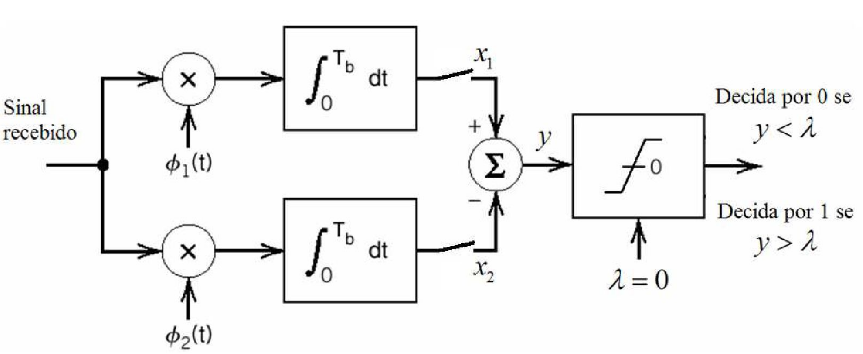

**Observações sobre os blocos:**

a) As funções-base $\phi_1(t)$ e $\phi_2(t)$ são as mesmas usadas na
   transmissão.

b) O **Correlator** multiplica o sinal recebido pela mesma função-base
   usada na modulação e integra o resultado a cada intervalo de símbolo
   $T_b$.

c) O bloco de **decisão** compara a subtração das duas projeções ($y = x_1
   - x_2$) com o limiar $\lambda = 0$: decide por 1 se $y > \lambda$, por
   0 se $y < \lambda$.

**O que fazer:**
1. Complete `demodula_bfsk`.
2. Aplique-a ao sinal da Seção 2.
3. Compare a sequência de bits demodulada com `params["bits"]` e confirme
   que são idênticas (canal ainda ideal, sem ruído).

In [15]:
Eb = 1.0
fs = 200_000

def modula_bfsk(bits, f1, f2, Tb, Eb, fs):

    """
    Retorna (t, s) onde:

      t : vetor de tempo

      s : sinal BFSK modulado, s(t)
    """

    n_amostras_por_bit = int(Tb * fs)

    t = np.arange(len(bits) * n_amostras_por_bit) / fs

    # Funções-base
    phi1 = np.sqrt(2 / Tb) * np.cos(2 * np.pi * f1 * t)
    phi2 = np.sqrt(2 / Tb) * np.cos(2 * np.pi * f2 * t)

    # Conversor NRZ unipolar
    nivel_bits = np.where(bits == 1, np.sqrt(Eb), 0)

    # Expande cada nível para todas as amostras do respectivo bit
    nivel = np.repeat(nivel_bits, n_amostras_por_bit)

    # Inversor de níveis
    nivel_inv = np.sqrt(Eb) - nivel

    # Sinal BFSK
    s = nivel * phi1 + nivel_inv * phi2

    return t, s

In [16]:
def demodula_bfsk(s, f1, f2, Tb, fs):

    """
    Retorna um array de bits demodulados a partir do sinal recebido s.
    """

    n_amostras_por_bit = int(Tb * fs)
    n_bits = len(s) // n_amostras_por_bit

    bits_rx = np.zeros(n_bits, dtype=int)

    for i in range(n_bits):

        inicio = i * n_amostras_por_bit
        fim = (i + 1) * n_amostras_por_bit

        trecho = s[inicio:fim]

        # Tempo absoluto correspondente a este bit
        t_bit = np.arange(inicio, fim) / fs

        # Funções-base
        phi1 = np.sqrt(2 / Tb) * np.cos(2 * np.pi * f1 * t_bit)
        phi2 = np.sqrt(2 / Tb) * np.cos(2 * np.pi * f2 * t_bit)

        # Correlação
        x1 = np.sum(trecho * phi1) / fs
        x2 = np.sum(trecho * phi2) / fs

        # Decisão
        y = x1 - x2

        bits_rx[i] = 1 if y > 0 else 0

    return bits_rx

In [17]:
t, s = modula_bfsk(
    params["bits"],
    params["f1"],
    params["f2"],
    params["Tb"],
    Eb,
    fs
)

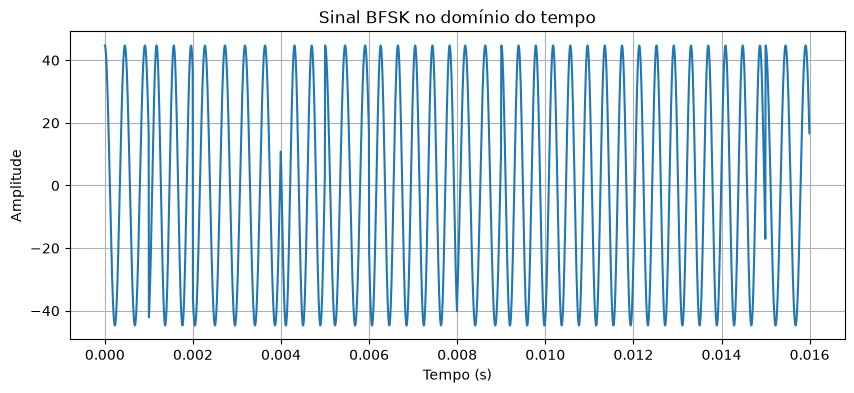

In [18]:
plt.figure()

plt.plot(t, s)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("Sinal BFSK no domínio do tempo")
plt.grid()

plt.show()

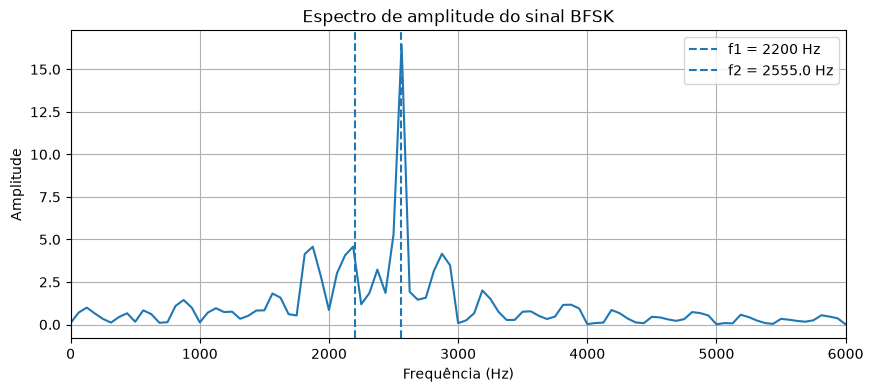

In [19]:
N = len(s)

S = np.fft.fft(s)
freq = np.fft.fftfreq(N, 1/fs)

# Apenas frequências positivas
mask = freq >= 0

plt.figure()

plt.plot(freq[mask], np.abs(S[mask]) / N)

plt.axvline(params["f1"], linestyle="--", label=f"f1 = {params['f1']} Hz")
plt.axvline(params["f2"], linestyle="--", label=f"f2 = {params['f2']} Hz")

plt.xlabel("Frequência (Hz)")
plt.ylabel("Amplitude")
plt.title("Espectro de amplitude do sinal BFSK")
plt.xlim(0, 6000)
plt.grid()
plt.legend()

plt.show()

In [20]:
bits_rx = demodula_bfsk(
    s,
    params["f1"],
    params["f2"],
    params["Tb"],
    fs
)

print("Bits originais:  ", params["bits"])
print("Bits demodulados:", bits_rx)
print("Identicos?", np.array_equal(params["bits"], bits_rx))

Bits originais:   [1 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1]
Bits demodulados: [1 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1]
Identicos? True


---
## 4. Canal com ruído (AWGN) e curva de BER

Um receptor que só funciona sem ruído não diz muito sobre um sistema de
comunicação real. Nesta seção você vai:

1. Implementar um canal AWGN que adiciona ruído gaussiano branco a $s(t)$
   para um dado $E_b/N_0$.
2. Gerar uma sequência **longa** de bits (não apenas 16 — use pelo menos
   $10^4$ bits) com os mesmos `f1`, `f2`, `Tb` da Seção 1.
3. Para uma faixa de $E_b/N_0$ (por exemplo, de 0 a 12 dB, em passos de 1
   ou 2 dB), simular transmissão + canal + recepção e calcular a BER
   (taxa de erro de bit) simulada.
4. Plotar a BER simulada (eixo y em escala log) versus $E_b/N_0$ (dB),
   **sobrepondo a curva teórica** da BFSK coerente ortogonal:
$$P_e = Q\!\left(\sqrt{\frac{E_b}{N_0}}\right), \qquad
  Q(x) = \frac{1}{2}\,\mathrm{erfc}\!\left(\frac{x}{\sqrt{2}}\right)$$

**Antes de rodar a simulação:** calcule à mão (ou em uma célula separada,
sem usar a LLM para o cálculo em si) o valor teórico de $P_e$ para pelo
menos dois pontos de $E_b/N_0$ da sua faixa, e anote o resultado em uma
célula de markdown — isso será conferido depois.

### Valores teóricos de BER

A expressão teórica para a BFSK coerente ortogonal é:

$$
P_e = Q\left(\sqrt{\frac{E_b}{N_0}}\right)
$$

com:

$$
Q(x)=\frac{1}{2}\operatorname{erfc}\left(\frac{x}{\sqrt{2}}\right)
$$

Para $E_b/N_0 = 0$ dB:

$$
\frac{E_b}{N_0}=10^{0/10}=1
$$

$$
P_e=Q(1)\approx0.1587
$$

Portanto:

$$
\boxed{P_e\approx15.87\%}
$$

Para $E_b/N_0 = 6$ dB:

$$
\frac{E_b}{N_0}=10^{6/10}\approx3.9811
$$

$$
P_e=Q(\sqrt{3.9811})
=Q(1.9953)
\approx0.0229
$$

Portanto:

$$
\boxed{P_e\approx2.29\%}
$$

In [21]:
def canal_awgn(s, EbN0_dB, Eb, Tb, fs):

    """Adiciona ruido gaussiano branco a s, para a relacao Eb/N0 (em dB) dada."""

    EbN0 = 10 ** (EbN0_dB / 10)
    N0 = Eb / EbN0

    var_ruido = N0 * fs / 2

    ruido = np.random.normal(
        0,
        np.sqrt(var_ruido),
        size=len(s)
    )

    return s + ruido


def calcula_ber(n_bits, EbN0_dB, f1, f2, Tb, Eb, fs, rng):

    bits = rng.integers(0, 2, size=n_bits)

    t, s = modula_bfsk(
        bits,
        f1,
        f2,
        Tb,
        Eb,
        fs
    )

    s_ruidoso = canal_awgn(
        s,
        EbN0_dB,
        Eb,
        Tb,
        fs
    )

    bits_rx = demodula_bfsk(
        s_ruidoso,
        f1,
        f2,
        Tb,
        fs
    )

    n_erros = np.sum(bits != bits_rx)

    return n_erros / n_bits

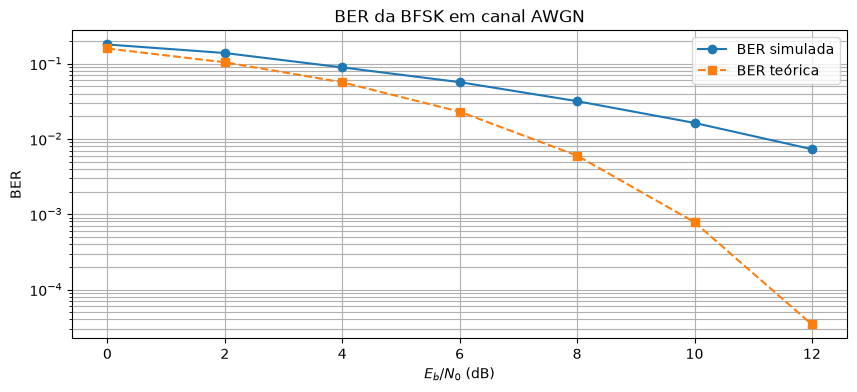

In [22]:
# Número de bits da simulação
n_bits = 10_000

# Faixa de Eb/N0 em dB
EbN0_dB_range = np.arange(0, 13, 2)

# RNG determinístico
rng = np.random.default_rng(params["seed"])

# BER simulada
ber_simulada = []

for EbN0_dB in EbN0_dB_range:

    ber = calcula_ber(
        n_bits,
        EbN0_dB,
        params["f1"],
        params["f2"],
        params["Tb"],
        Eb,
        fs,
        rng
    )

    ber_simulada.append(ber)

# BER teórica da BFSK coerente ortogonal
ber_teorica = 0.5 * erfc(
    np.sqrt(10**(np.array(EbN0_dB_range) / 10)) / np.sqrt(2)
)

# Gráfico
plt.figure()

plt.semilogy(
    EbN0_dB_range,
    ber_simulada,
    'o-',
    label="BER simulada"
)

plt.semilogy(
    EbN0_dB_range,
    ber_teorica,
    's--',
    label="BER teórica"
)

plt.xlabel("$E_b/N_0$ (dB)")
plt.ylabel("BER")
plt.title("BER da BFSK em canal AWGN")
plt.grid(True, which="both")
plt.legend()

plt.show()

---
## 5. Ocupação espectral

Usando o sinal $s(t)$ **sem ruído** da Seção 2:

1. Estime a largura de banda ocupada pelo sinal BFSK (por exemplo, banda
   que contém 99% da energia do sinal, ou usando a regra de Carson para
   FSK).
2. Compare essa largura de banda com o espaçamento $|f_2 - f_1|$ dos seus
   parâmetros individualizados.
3. Relacione esse resultado com as faixas ISM (433 MHz,
   915 MHz, 2,4 GHz, 5,8 GHz): supondo que seu sinal fosse transladado
   para operar dentro de uma dessas faixas, ele caberia dentro dos
   limites de banda tipicamente licenciados para aquela faixa? Justifique.

In [23]:
# FFT do sinal BFSK sem ruído
N = len(s)

S = np.fft.rfft(s)
freq = np.fft.rfftfreq(N, 1/fs)

# Energia espectral
energia = np.abs(S)**2
energia = energia / np.sum(energia)

# Frequência central do BFSK
fc = (params["f1"] + params["f2"]) / 2

# Procura a menor largura de banda centrada em fc
# que contenha pelo menos 99% da energia
larguras = np.arange(0, freq[-1] - freq[0], freq[1])

for B in larguras:
    f_min = fc - B/2
    f_max = fc + B/2

    mascara = (freq >= f_min) & (freq <= f_max)

    energia_banda = np.sum(energia[mascara])

    if energia_banda >= 0.99:
        banda_99 = B
        break

print(f"f1 = {params['f1']} Hz")
print(f"f2 = {params['f2']} Hz")
print(f"fc = {fc:.1f} Hz")
print(f"Largura de banda (99% da energia) ≈ {banda_99:.1f} Hz")

f1 = 2200 Hz
f2 = 2555.0 Hz
fc = 2377.5 Hz
Largura de banda (99% da energia) ≈ 7750.0 Hz


In [24]:
delta_f = abs(params["f2"] - params["f1"])

print(f"|f2 - f1| = {delta_f:.1f} Hz")
print(f"Largura de banda 99% ≈ {banda_99:.1f} Hz")
print(f"Razão B99 / |f2-f1| ≈ {banda_99 / delta_f:.2f}")

|f2 - f1| = 355.0 Hz
Largura de banda 99% ≈ 7750.0 Hz
Razão B99 / |f2-f1| ≈ 21.83


### Análise da ocupação espectral

Para os parâmetros individualizados obtidos:

$$
f_1=2200\text{ Hz}
$$

$$
f_2=2555\text{ Hz}
$$

O espaçamento entre as duas frequências é:

$$
|f_2-f_1|=|2555-2200|=355\text{ Hz}
$$

A frequência central do sinal é:

$$
f_c=\frac{f_1+f_2}{2}=2377,5\text{ Hz}
$$

Utilizando o critério de 99% da energia espectral, foi obtida uma largura
de banda aproximada de:

$$
B_{99\%}\approx7750\text{ Hz}
$$

Assim, a largura de banda ocupada é aproximadamente 21,83 vezes maior
que o espaçamento entre as duas frequências:

$$
\frac{B_{99\%}}{|f_2-f_1|}
\approx21,83
$$

Isso mostra que o espaçamento $|f_2-f_1|$ não representa a largura de
banda total do sinal BFSK. A modulação possui energia espectral espalhada
ao redor das frequências $f_1$ e $f_2$, principalmente devido às
transições entre bits e à duração finita dos símbolos.

### Relação com as faixas ISM

A largura de banda obtida pelo critério de 99% da energia foi:

$$
B_{99\%}\approx 7750\text{ Hz}=7,75\text{ kHz}
$$

Essa largura de banda é muito pequena quando comparada à escala das
faixas ISM de 433 MHz, 915 MHz, 2,4 GHz e 5,8 GHz.

Portanto, se o sinal BFSK fosse transladado em frequência para uma dessas
faixas, sua largura de banda continuaria sendo aproximadamente 7,75 kHz.
Em termos de largura de banda disponível, o sinal ocuparia uma pequena
parcela da faixa e, portanto, caberia dentro dela.

Entretanto, isso não significa que qualquer frequência dentro dessas
faixas possa ser utilizada livremente. A operação real depende da
regulamentação aplicável, incluindo limites de potência, canalização,
máscara espectral e outras restrições.

Assim, considerando apenas a largura de banda, o sinal BFSK poderia ser
acomodado em uma dessas faixas ISM.

---
## 6. Perguntas "e se...?"

Responda em células de markdown, com justificativa técnica (não apenas a
conclusão). Estas perguntas **não têm uma resposta que se obtenha apenas
rodando o código anterior** — exigem que você raciocine sobre o que
aconteceria.

1. **Ortogonalidade:** verifique se o seu `fator_delta` (Seção 1) é maior
   ou menor que 1. Se for menor que 1, suas frequências $f_1$ e $f_2$
   **não** satisfazem rigorosamente a condição clássica de ortogonalidade
   $\Delta f = 1/(2T_b)$ para detecção coerente. Isso afetou visivelmente
   a BER medida na Seção 4? Por quê (ou por que não)?

2. **E se $T_b$ dobrasse** (símbolos duas vezes mais longos), mantendo
   $f_1$, $f_2$ e $E_b/N_0$ fixos? O que aconteceria com a BER? E com a
   banda ocupada (Seção 5)? Justifique com base na teoria, não apenas
   rodando a simulação.

3. **E se o receptor não tivesse sincronismo perfeito** com o transmissor
   (ou seja, $\phi_1(t)$ e $\phi_2(t)$ usados no receptor estivessem
   levemente defasados em relação aos do transmissor)? Qual seria o efeito
   esperado sobre $x_1$ e $x_2$, e por consequência sobre a decisão?
   (Não é necessário simular — descreva o raciocínio.)

4. **Modo de falha mais provável:** dado tudo o que você observou neste
   laboratório, qual você diria que é o modo de falha mais provável de um
   sistema BFSK coerente como este em uma aplicação real (por exemplo,
   controle remoto em 433 MHz)? Justifique.

### 6.1 — Ortogonalidade

O fator de espaçamento obtido na Seção 1 foi:

$$
\text{fator}_{\Delta}=0,71
$$

Como:

$$
T_b=1\,\text{ms}
$$

a separação mínima para a condição clássica de ortogonalidade coerente é:

$$
\Delta f_{\min}=\frac{1}{2T_b}
=\frac{1}{2(0,001)}
=500\,\text{Hz}
$$

Para os parâmetros deste experimento:

$$
f_1=2200\,\text{Hz}
$$

$$
f_2=2555\,\text{Hz}
$$

e portanto:

$$
\Delta f=f_2-f_1=355\,\text{Hz}
$$

Assim:

$$
\frac{\Delta f}{\Delta f_{\min}}
=\frac{355}{500}
=0,71<1
$$

Logo, as duas funções-base não são rigorosamente ortogonais.

Isso afetou a BER observada na Seção 4. A expressão teórica utilizada,
$$
P_e=Q\left(\sqrt{\frac{E_b}{N_0}}\right),
$$
é válida para BFSK coerente ortogonal, enquanto o sistema simulado possui
$\Delta f < 1/(2T_b)$.

Como as funções-base não são ortogonais, temos:

$$
\int_0^{T_b}\phi_1(t)\phi_2(t)\,dt\neq0
$$

Portanto, a projeção sobre uma função-base contém também uma contribuição
da outra frequência. Isso reduz a separação efetiva entre as decisões
$x_1$ e $x_2$, tornando o receptor mais suscetível ao ruído.

Isso é coerente com o resultado observado na Seção 4: a BER simulada
ficou acima da BER teórica da BFSK coerente ortogonal, principalmente para
valores maiores de $E_b/N_0$.

### 6.2 — Dobrar o tempo de símbolo

Inicialmente temos:

$$
T_b=1\,ms
$$

e:

$$
\Delta f=f_2-f_1=2555-2200=355\,Hz
$$

Se o tempo de símbolo for dobrado:

$$
T_b'=2T_b=2\,ms
$$

a separação mínima necessária para a ortogonalidade passa a ser:

$$
\Delta f_{\min}'=
\frac{1}{2T_b'}
=
\frac{1}{2(0,002)}
=
250\,Hz
$$

Como:

$$
\Delta f=355\,Hz>250\,Hz
$$

as duas frequências passam a satisfazer a condição clássica de
ortogonalidade coerente.

Assim, espera-se uma redução da BER em relação ao caso original,
pois a interferência entre as funções-base deixa de existir
idealmente. Como $E_b/N_0$ é mantido constante, a BER tende a se
aproximar da expressão teórica da BFSK coerente ortogonal:

$$
P_e=Q\left(\sqrt{\frac{E_b}{N_0}}\right)
$$

Além disso, ao dobrar $T_b$, a taxa de bits é reduzida pela metade:

$$
R_b=\frac{1}{T_b}
$$

portanto:

$$
R_b'=500\,bit/s
$$

contra os $1000\,bit/s$ originais.

Uma taxa de símbolos menor reduz o espalhamento espectral causado
pelas transições entre $f_1$ e $f_2$. Portanto, a largura de banda
ocupada pelo sinal também tende a diminuir.

Usando a aproximação de Carson, com:

$$
\Delta f_{dev}=\frac{355}{2}=177,5\,Hz
$$

e aproximando $f_m\approx R_b/2$, temos inicialmente:

$$
B\approx2(177,5+500)=1355\,Hz
$$

Após dobrar $T_b$:

$$
B'\approx2(177,5+250)=855\,Hz
$$

Portanto, dobrar o tempo de símbolo faz com que a BER melhore neste
caso, pois as frequências passam a ser ortogonais, e também reduz a
largura de banda ocupada devido à menor taxa de símbolos.

### 6.3 — Falta de sincronização de fase

O receptor coerente utilizado calcula as correlações:

$$
x_1=\int_0^{T_b}s(t)\phi_1(t)\,dt
$$

e

$$
x_2=\int_0^{T_b}s(t)\phi_2(t)\,dt
$$

e realiza a decisão a partir de:

$$
y=x_1-x_2
$$

Esse processo pressupõe que as funções-base utilizadas pelo receptor
estejam sincronizadas em fase com as utilizadas pelo transmissor.

Se houver um erro de fase $\theta$, por exemplo, a referência do
receptor pode ser escrita como:

$$
\hat{\phi}_1(t)=
\sqrt{\frac{2}{T_b}}
\cos(2\pi f_1t+\theta)
$$

A correlação entre o sinal recebido e a referência passa a depender
do termo:

$$
\cos(\theta)
$$

Assim, a componente útil da correlação diminui conforme aumenta o
erro de fase. Por exemplo:

$$
\theta=0^\circ \Rightarrow \cos(\theta)=1
$$

$$
\theta=60^\circ \Rightarrow \cos(\theta)=0,5
$$

$$
\theta=90^\circ \Rightarrow \cos(\theta)=0
$$

Portanto, um erro de fase reduz a magnitude das projeções $x_1$ e
$x_2$, diminuindo a separação entre as duas possíveis decisões.

Consequentemente, o receptor fica mais suscetível ao ruído e a
probabilidade de erro aumenta:

$$
\boxed{
\text{erro de fase}
\rightarrow
\text{menor correlação}
\rightarrow
\text{menor margem de decisão}
\rightarrow
\text{maior BER}
}
$$

Em uma situação extrema, com um erro de fase próximo de $90^\circ$,
a correlação com a componente desejada pode se aproximar de zero,
tornando a decisão muito difícil.

Portanto, um receptor BFSK coerente necessita de uma boa sincronização
de fase entre o transmissor e as referências utilizadas pelo receptor.

### 6.4 — Principal fonte de falha em uma aplicação real

Em uma aplicação real, como um controle remoto operando em 433 MHz,
uma das principais fontes de falha de um sistema BFSK coerente é a
falta de sincronização adequada entre transmissor e receptor.

No experimento, assumimos que o receptor conhece perfeitamente as
frequências $f_1$ e $f_2$, a fase das portadoras e o instante de início
de cada símbolo. Em um sistema real, entretanto, os osciladores
possuem tolerâncias e podem sofrer variações devido à temperatura,
envelhecimento e diferenças entre os componentes.

Assim, o receptor pode apresentar um erro de frequência:

$$
f_{RX}=f_{TX}+\Delta f_{erro}
$$

Esse erro reduz a correlação entre o sinal recebido e a função-base
utilizada pelo receptor.

Além disso, erros na sincronização temporal podem fazer com que o
receptor integre o sinal em um intervalo diferente do intervalo real
do símbolo. Isso também reduz a eficiência da detecção.

Consequentemente:

$$
\text{erro de frequência/fase/tempo}
\rightarrow
\text{menor correlação}
\rightarrow
\text{decisão menos confiável}
\rightarrow
\text{maior BER}
$$

Outros fatores também podem causar erros em uma aplicação real, como
ruído, interferência de outros dispositivos, atenuação e
multipercurso. Porém, em um sistema BFSK coerente, a sincronização é
especialmente importante porque o receptor depende diretamente das
funções-base utilizadas na correlação.

Portanto, a principal dificuldade prática seria manter uma referência
de frequência, fase e temporização suficientemente precisa para que o
receptor consiga realizar a detecção coerente corretamente.

---
## 7. Log de uso de IA

Preencha a tabela abaixo com cada interação relevante que você teve com uma
LLM (ChatGPT, Claude, Copilot, etc.) durante este laboratório. Isso é
tratado como **citação de fonte**, não como delação — o objetivo é
documentar seu processo, não penalizar o uso da ferramenta.

| # | Seção do lab | Prompt (resumo) | O que a IA sugeriu | O que você validou/mudou e por quê |
|---|---|---|---|---|
| 1 | 3 | Complete os TODO | Código | |
| 2 | 3 | Faça uma função de demodulação para comparação | Código | |
| 3 | 4 | Reescreva minhas equações em markdown | Código | |
| 4 | 4 | Reescreva minhas equações em markdown | Código | |
| 5 | 4 | Plotar BER terórico x simulado | Código | |
| 6 | 5 | Estimar largura de banda, comparar com f2-f1 e relacionar isso com faixas ISM | Código | |
| 7 | 6 | (Majoritariamente reescrever minhas palavras em markdown) | Código | |


Adicione quantas linhas forem necessárias. Se você não usou IA em alguma
seção, não é preciso preencher uma linha para ela.

---
## 8. Entregáveis

- Este notebook preenchido (`.ipynb`), com todas as células executadas e
  os gráficos visíveis (não apenas o código).
- A célula de cálculo teórico manual da Seção 4 (os dois pontos de $P_e$
  calculados antes da simulação).
- As respostas da Seção 6 (perguntas "e se...?").
- O log de uso de IA preenchido (Seção 7).
